# 06.3 · Gamma and unsharp masking

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain gamma and unsharp masking using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[05 · Image Processing](../../05-image-processing/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Enhancement changes appearance so a useful signal is easier to inspect or process. Brightness shifts intensity, contrast changes separation, and a histogram counts how often each intensity occurs. Enhancement should serve a task; a visually dramatic image is not automatically more informative.

## 2. Intuition

Gamma correction is a nonlinear pointwise map. With normalized input and the convention output=input**gamma, gamma below one brightens midtones. Unsharp masking adds a scaled difference between the original image and a blurred copy. Both clipping and color-space choices affect the result; sharpening can create halos around edges.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 6
LESSON = 2
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
y=x^\gamma\quad (0\le x\le1)
$$

x is normalized input intensity, y the corrected intensity and γ the chosen exponent. With x=0.25 and γ=0.5, y=0.5. This definition must be stated because some tools expose reciprocal gamma.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
x = np.array([0.0, 0.25, 0.5, 1.0])
gamma = 0.5
y = x**gamma
assert np.isclose(y[1], 0.5)
print(y)

[0.         0.5        0.70710678 1.        ]


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The lab computes a NumPy CDF mapping, compares OpenCV equalization, then examines CLAHE and sharpening. The plotted histograms show counts, not probabilities unless normalized.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def filtering(lesson, seed, amount):
    clean = n.gray(picture(seed))/255
    rng = np.random.default_rng(seed)
    if lesson == 1:
        noisy = clean.copy(); noise = rng.random(clean.shape)
        noisy[noise < .04*amount] = 0; noisy[noise > 1-.04*amount] = 1
        output = median_filter(noisy,size=3)
        comparison = cv2.medianBlur((noisy*255).astype(np.uint8),3)/255
    else:
        noisy = np.clip(clean+rng.normal(0,.08*amount,clean.shape),0,1)
        kernel = n.gaussian_kernel(5,1 if lesson==0 else 1.7)
        output = n.correlate(noisy,kernel)
        comparison = cv2.filter2D(noisy,-1,kernel,borderType=cv2.BORDER_REPLICATE)
    return Result('05 · Noise and local filtering',{'Clean':clean,'Noisy':noisy,'Reference output':output,'OpenCV comparison':comparison}, metrics={'noisy_mse':float(np.mean((clean-noisy)**2)),'filtered_mse':float(np.mean((clean-output)**2)),'library_max_error':float(np.max(np.abs(output-comparison)))})

{
  "input_std": 11.601336897843867,
  "output_std": 11.601336897843867
}
Contrast spread is descriptive, not a perceptual quality score.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import equalize

display(Code(inspect.getsource(equalize), language="python"))

def equalize(image):
    """Histogram equalization with the first occupied CDF bin subtracted."""
    image = np.asarray(image, dtype=np.uint8)
    counts = np.bincount(image.ravel(), minlength=256)
    cdf = counts.cumsum()
    first = cdf[counts > 0][0]
    if cdf[-1] == first:
        return image.copy()
    table = np.rint((cdf-first)/(cdf[-1]-first)*255).clip(0, 255).astype(np.uint8)
    return table[image]

## 8. Experiment

Increase CLAHE strength on a noisy flat region and quantify both local contrast and noise variance. Find a setting that improves the downstream threshold mask.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "input_std": 11.601336897843867,
    "output_std": 11.601336897843867
  },
  "second_seed": {
    "input_std": 11.60016839427689,
    "output_std": 11.60016839427689
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

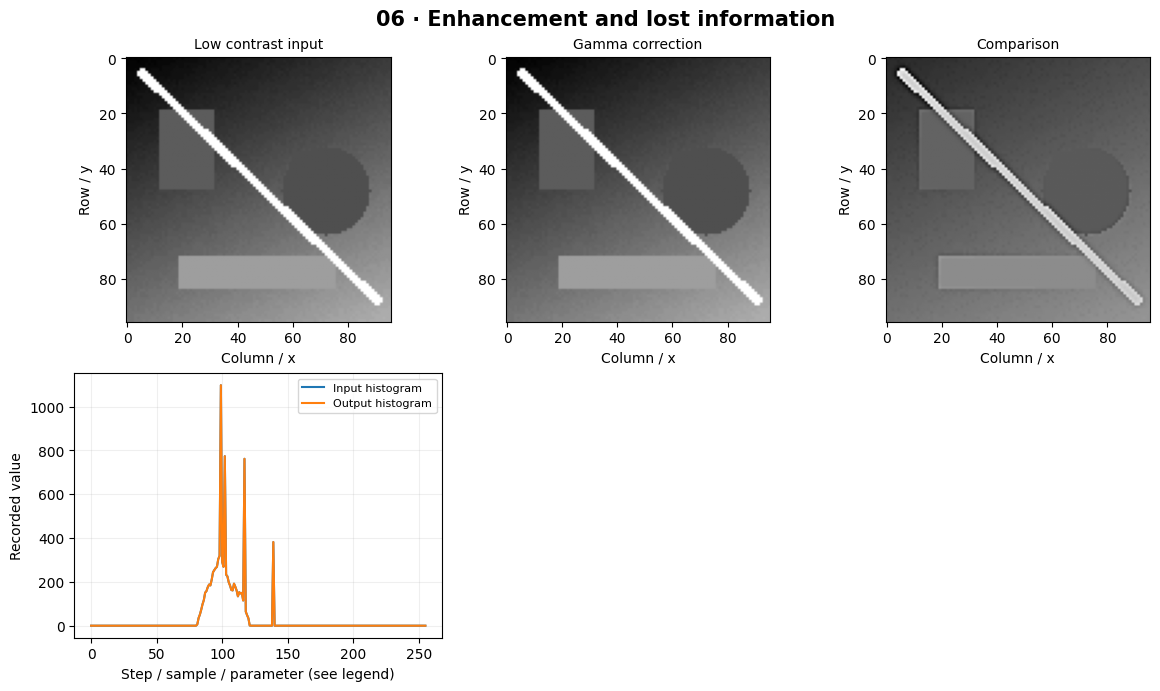

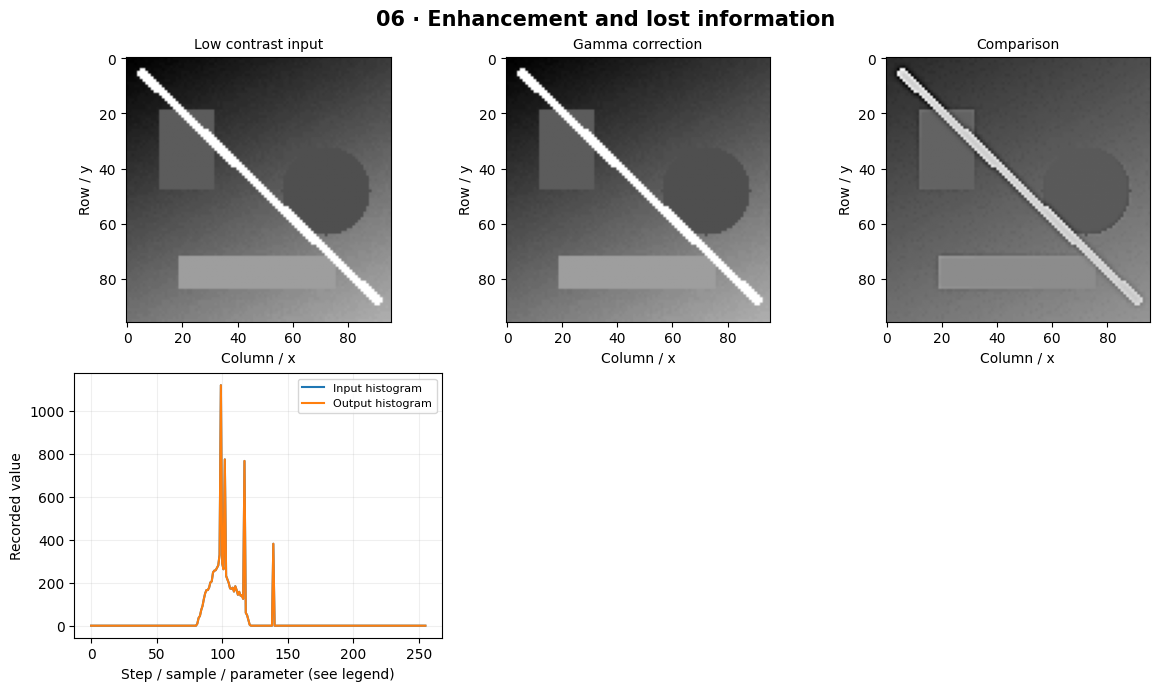

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Image Enhancement Studio**. Choose an enhancement method using image evidence. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Equalizing R, G and B independently can change hue. Clipping after sharpening discards values and can hide overshoot.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Increase CLAHE strength on a noisy flat region and quantify both local contrast and noise variance. Find a setting that improves the downstream threshold mask.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build an enhancement studio with saved parameter presets and a side-by-side comparison on dark, backlit and noisy images.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Gamma correction is a nonlinear pointwise map. With normalized input and the convention output=input**gamma, gamma below one brightens midtones. Unsharp masking adds a scaled difference between the original image and a blurred copy. Both clipping and color-space choices affect the result; sharpening can create halos around edges.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

[07 · Geometric Transformations](../../07-geometric-transformations/README.md)

[Primary reference](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)